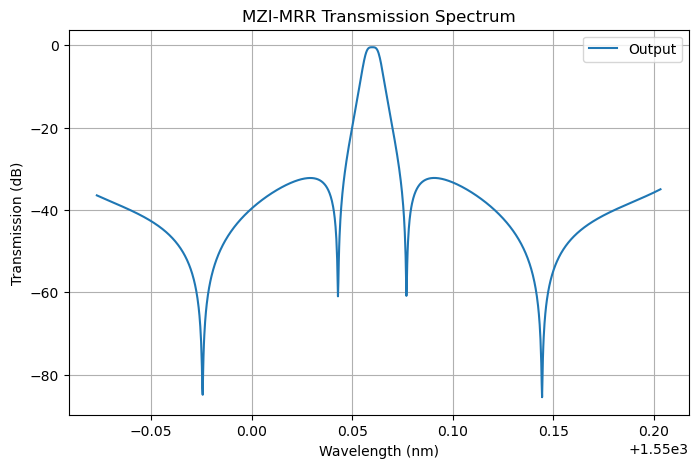

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 参数定义
# ===============================
f = np.arange(1.93523e14, 1.93558e14 + 0.00000025e14, 0.00000025e14)
c = 3e8

E1 = 0
E2 = 1

Ki = 0.5  # 3dB耦合器功率耦合系数
Ko = 0.5
ai = np.sqrt(1 - Ki)
bi = -1j * np.sqrt(Ki)
ao = np.sqrt(1 - Ko)
bo = -1j * np.sqrt(Ko)

thetai = 0.5 * np.pi  # MZI上臂相移
thetao = 0.5 * np.pi

fait = 0.495 * np.pi  # MZI上臂相移
faib = -0.495 * np.pi  # MZI下臂相移

fai1 = -0.0468 * np.pi
fai2 = -0.6842 * np.pi
fai3 = -0.0518 * np.pi
fai4 = -0.6198 * np.pi

theta1 = -0.622 * np.pi
theta2 = -0.73 * np.pi
theta3 = -0.622 * np.pi
theta4 = -0.73 * np.pi

k = np.cos(theta1 / 2)
t = np.sqrt(1 - k ** 2)

Alfadb = 15  # 功率损耗因子
alfadb = Alfadb / 2  # 场强损耗因子
alfa = alfadb * np.log(10) / 10
neff = 2.2998
ng = 4.3
L1 = 350e-6
L3 = 350e-6
L2 = 3000e-6
L4 = 3000e-6

fsr1 = c / (L1 * ng)  # 微环FSR
fsr2 = c / (L2 * ng)
tao1 = np.exp(-alfa * L1)
tao2 = np.exp(-alfa * L2)
tao3 = np.exp(-alfa * L3)
tao4 = np.exp(-alfa * L4)

# ===============================
# 计算各臂的相位延迟
# ===============================
fai11 = 2 * np.pi * f * L1 * ng / c
fai22 = 2 * np.pi * f * L2 * ng / c
fai33 = 2 * np.pi * f * L3 * ng / c
fai44 = 2 * np.pi * f * L4 * ng / c

# ===============================
# 输入耦合
# ===============================
E3 = np.sqrt(1 - Ki) * E1 - 1j * np.sqrt(Ki) * E2
E4 = -1j * np.sqrt(Ki) * E1 + np.sqrt(1 - Ki) * E2
E5 = E3
E6 = np.exp(1j * thetai) * E4
E7 = np.sqrt(1 - Ki) * E5 - 1j * np.sqrt(Ki) * E6
E8 = -1j * np.sqrt(Ki) * E5 + np.sqrt(1 - Ki) * E6

# ===============================
# 频率扫描
# ===============================
N = len(f)

C1 = np.zeros(N)
C2 = np.zeros(N)

for i in range(N):
    c1 = ((np.exp(1j * theta1) - 1) / 2 - tao1 * np.exp(1j * (fai1 + theta1 + fai11[i]))) / (
            1 - tao1 * (1 - np.exp(1j * theta1)) * np.exp(1j * (fai11[i] + fai1)) / 2)
    c2 = ((np.exp(1j * theta2) - 1) / 2 - tao2 * np.exp(1j * (fai2 + theta2 + fai22[i]))) / (
            1 - tao2 * (1 - np.exp(1j * theta2)) * np.exp(1j * (fai22[i] + fai2)) / 2)
    A1 = np.exp(1j * fait) * c1 * c2

    c3 = ((np.exp(1j * theta3) - 1) / 2 - tao3 * np.exp(1j * (fai3 + theta3 + fai33[i]))) / (
            1 - tao3 * (1 - np.exp(1j * theta3)) * np.exp(1j * (fai33[i] + fai3)) / 2)
    c4 = ((np.exp(1j * theta4) - 1) / 2 - tao4 * np.exp(1j * (fai4 + theta4 + fai44[i]))) / (
            1 - tao4 * (1 - np.exp(1j * theta4)) * np.exp(1j * (fai44[i] + fai4)) / 2)
    A2 = np.exp(1j * faib) * c3 * c4

    E9 = A1 * E7
    E10 = A2 * E8
    E11 = np.sqrt(1 - Ko) * E9 - 1j * np.sqrt(Ko) * E10
    E12 = -1j * np.sqrt(Ko) * E9 + np.sqrt(1 - Ko) * E10
    E13 = E11
    E14 = np.exp(1j * thetao) * E12
    E15 = np.sqrt(1 - Ko) * E13 - 1j * np.sqrt(Ko) * E14
    E16 = -1j * np.sqrt(Ko) * E13 + np.sqrt(1 - Ko) * E14

    C1[i] = np.abs(E15) ** 2
    C2[i] = np.abs(E16) ** 2

CdB1 = 10 * np.log10(C1)
CdB2 = 10 * np.log10(C2)

# ===============================
# 计算波长
# ===============================
lambda_ = c / f

# ===============================
# 绘图
# ===============================
plt.figure(figsize=(8, 5))
plt.plot(lambda_ * 1e9, CdB2, label='Output')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission (dB)')
plt.title('MZI-MRR Transmission Spectrum')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# =====================================
# 主计算函数
# =====================================
def MZI_MRR(fait_val, faib_val, fai1_val, fai2_val, fai3_val, fai4_val, 
             theta1_val, theta2_val, theta3_val, theta4_val):

    # ===== 固定参数 =====
    f = np.arange(1.93523e14, 1.93558e14 + 0.00000025e14, 0.00000025e14)
    c = 3e8
    E1, E2 = 0, 1
    Ki, Ko = 0.5, 0.5
    thetai = 0.5 * np.pi
    thetao = 0.5 * np.pi

    Alfadb = 15
    alfadb = Alfadb / 2
    alfa = alfadb * np.log(10) / 10
    ng = 4.3
    L1, L2, L3, L4 = 350e-6, 3000e-6, 350e-6, 3000e-6

    tao1, tao2, tao3, tao4 = [np.exp(-alfa * L) for L in [L1, L2, L3, L4]]

    # ===== 相位延迟 =====
    fai11 = 2 * np.pi * f * L1 * ng / c
    fai22 = 2 * np.pi * f * L2 * ng / c
    fai33 = 2 * np.pi * f * L3 * ng / c
    fai44 = 2 * np.pi * f * L4 * ng / c

    # ===== 输入耦合 =====
    E3 = np.sqrt(1 - Ki) * E1 - 1j * np.sqrt(Ki) * E2
    E4 = -1j * np.sqrt(Ki) * E1 + np.sqrt(1 - Ki) * E2
    E5, E6 = E3, np.exp(1j * thetai) * E4
    E7 = np.sqrt(1 - Ki) * E5 - 1j * np.sqrt(Ki) * E6
    E8 = -1j * np.sqrt(Ki) * E5 + np.sqrt(1 - Ki) * E6

    # ===== 频率扫描 =====
    N = len(f)
    C2 = np.zeros(N)

    for i in range(N):
        c1 = ((np.exp(1j * theta1_val) - 1) / 2 - tao1 * np.exp(1j * (fai1_val + theta1_val + fai11[i]))) / (
                1 - tao1 * (1 - np.exp(1j * theta1_val)) * np.exp(1j * (fai11[i] + fai1_val)) / 2)
        c2 = ((np.exp(1j * theta2_val) - 1) / 2 - tao2 * np.exp(1j * (fai2_val + theta2_val + fai22[i]))) / (
                1 - tao2 * (1 - np.exp(1j * theta2_val)) * np.exp(1j * (fai22[i] + fai2_val)) / 2)
        A1 = np.exp(1j * fait_val) * c1 * c2

        c3 = ((np.exp(1j * theta3_val) - 1) / 2 - tao3 * np.exp(1j * (fai3_val + theta3_val + fai33[i]))) / (
                1 - tao3 * (1 - np.exp(1j * theta3_val)) * np.exp(1j * (fai33[i] + fai3_val)) / 2)
        c4 = ((np.exp(1j * theta4_val) - 1) / 2 - tao4 * np.exp(1j * (fai4_val + theta4_val + fai44[i]))) / (
                1 - tao4 * (1 - np.exp(1j * theta4_val)) * np.exp(1j * (fai44[i] + fai4_val)) / 2)
        A2 = np.exp(1j * faib_val) * c3 * c4

        E9, E10 = A1 * E7, A2 * E8
        E11 = np.sqrt(1 - Ko) * E9 - 1j * np.sqrt(Ko) * E10
        E12 = -1j * np.sqrt(Ko) * E9 + np.sqrt(1 - Ko) * E10
        E13 = E11
        E14 = np.exp(1j * thetao) * E12
        E15 = np.sqrt(1 - Ko) * E13 - 1j * np.sqrt(Ko) * E14
        E16 = -1j * np.sqrt(Ko) * E13 + np.sqrt(1 - Ko) * E14

        C2[i] = np.abs(E16) ** 2

    CdB2 = 10 * np.log10(C2)
    lambda_ = c / f

    # ===== 绘图 =====
    plt.figure(figsize=(7, 4))
    plt.plot(lambda_ * 1e9, CdB2, color='royalblue')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Transmission (dB)')
    plt.title('MZI-MRR Spectrum (Interactive)')
    plt.grid(True)
    plt.show()


# =====================================
# 交互界面
# =====================================
interact(
    MZI_MRR,
    fait_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=0.495*np.pi, description='fait'),
    faib_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.495*np.pi, description='faib'),
    fai1_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.0468*np.pi, description='fai1'),
    fai2_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.6842*np.pi, description='fai2'),
    fai3_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.0518*np.pi, description='fai3'),
    fai4_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.6198*np.pi, description='fai4'),
    theta1_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.622*np.pi, description='theta1'),
    theta2_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.73*np.pi, description='theta2'),
    theta3_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.622*np.pi, description='theta3'),
    theta4_val=FloatSlider(min=-np.pi, max=np.pi, step=0.01, value=-0.73*np.pi, description='theta4')
);

interactive(children=(FloatSlider(value=1.5550883635269477, description='fait', max=3.141592653589793, min=-3.…